# Ex-Post Variance Risk Premium Analysis

VRP_expost = atm_iv - sqrt(rv_21d_forward)

Both sides in annualized vol space. Positive = implied vol overpriced realized vol (vol sellers profited).

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
import sys
sys.path.insert(0, "..")
from theta.analysis.vrp import compute_expost_vrp, symbol_summary, monthly_vrp, extreme_days

panel = pl.read_parquet("../data/processed/panel.parquet")
df = compute_expost_vrp(panel)
sym = symbol_summary(df)
monthly = monthly_vrp(df)
top, bottom = extreme_days(df, n=20)

print(f"Panel: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Symbols: {df['symbol'].n_unique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Panel: 189,006 rows x 49 cols
Symbols: 193
Date range: 2022-01-03 to 2026-03-19


## 1. Overall VRP Distribution

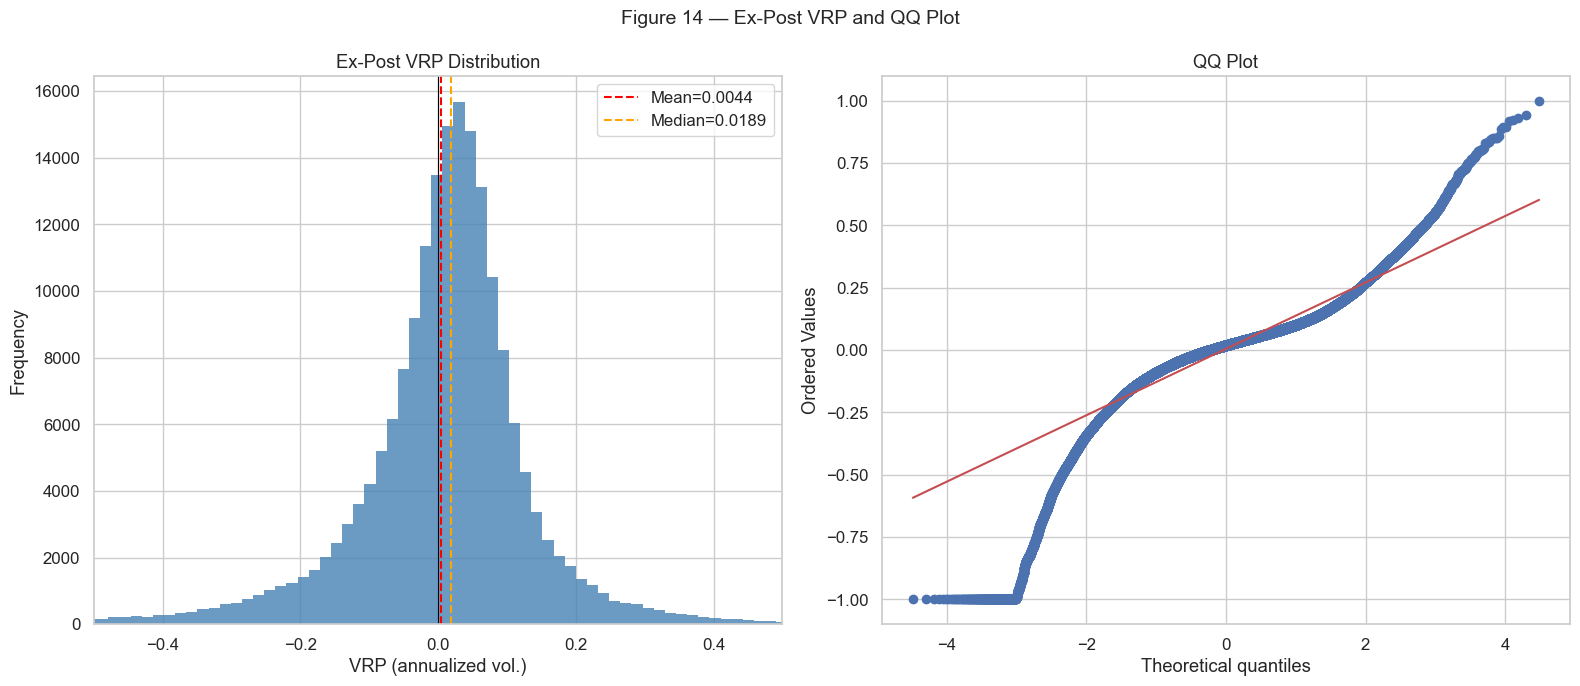

Mean: 0.0044  Median: 0.0189  Std: 0.1438
Skew: -1.56  Kurtosis: 10.61
Win rate: 59.0%


In [3]:
vrp = df["vrp_expost"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Histogram
axes[0].hist(vrp, bins=150, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(np.mean(vrp), color="red", ls="--", label=f"Mean={np.mean(vrp):.4f}")
axes[0].axvline(np.median(vrp), color="orange", ls="--", label=f"Median={np.median(vrp):.4f}")
axes[0].axvline(0, color="black", ls="-", lw=0.8)
axes[0].set_xlim(-0.5, 0.5)
axes[0].set_xlabel("VRP (annualized vol.)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Ex-Post VRP Distribution")
axes[0].legend()

# QQ plot
from scipy import stats
stats.probplot(np.clip(vrp, -1, 1), plot=axes[1])
axes[1].set_title("QQ Plot")

fig.suptitle("Figure 14 — Ex-Post VRP and QQ Plot", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Mean: {np.mean(vrp):.4f}  Median: {np.median(vrp):.4f}  Std: {np.std(vrp):.4f}")
print(f"Skew: {stats.skew(vrp):.2f}  Kurtosis: {stats.kurtosis(vrp):.2f}")
print(f"Win rate: {(vrp > 0).mean():.1%}")

## 2. VRP Over Time (Cross-Sectional Average)

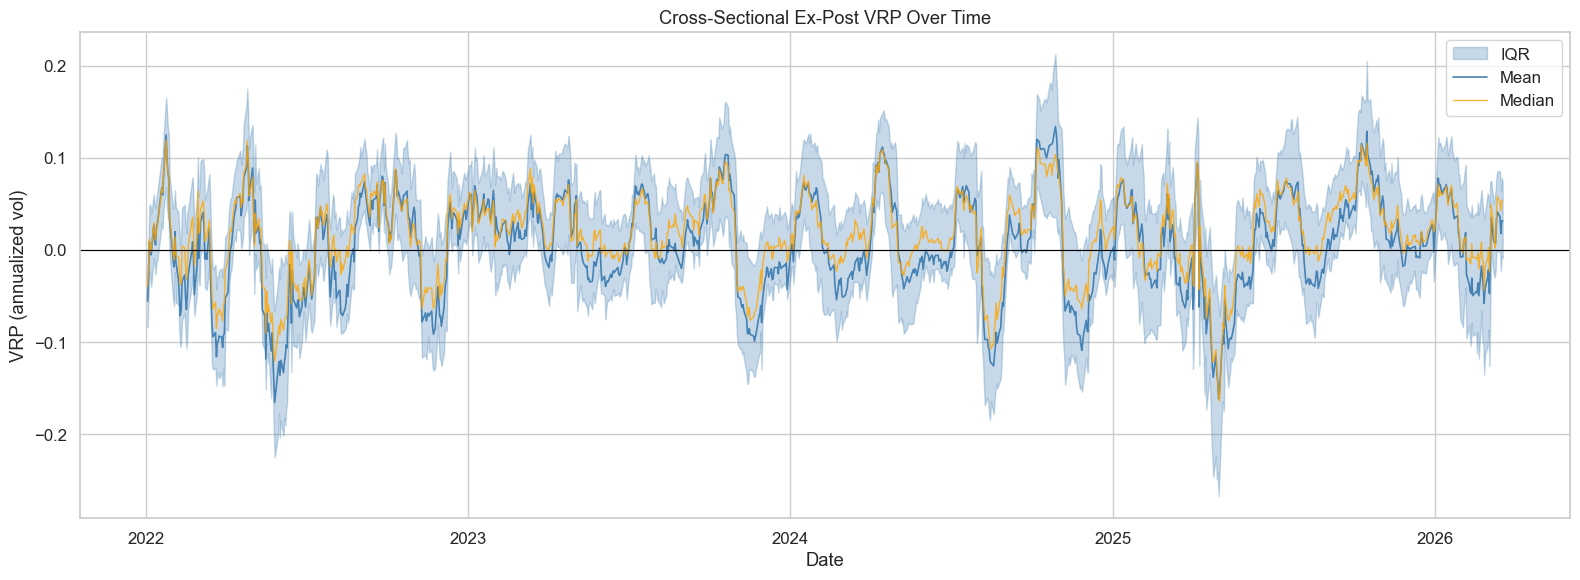

In [4]:
daily_vrp = (
    df.group_by("date")
    .agg(
        pl.col("vrp_expost").mean().alias("mean_vrp"),
        pl.col("vrp_expost").median().alias("median_vrp"),
        pl.col("vrp_expost").quantile(0.25).alias("q25"),
        pl.col("vrp_expost").quantile(0.75).alias("q75"),
    )
    .sort("date")
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(daily_vrp["date"], daily_vrp["q25"], daily_vrp["q75"],
                alpha=0.3, color="steelblue", label="IQR")
ax.plot(daily_vrp["date"], daily_vrp["mean_vrp"], color="steelblue", lw=1.2, label="Mean")
ax.plot(daily_vrp["date"], daily_vrp["median_vrp"], color="orange", lw=1, alpha=0.8, label="Median")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("VRP (annualized vol)")
ax.set_title("Cross-Sectional Ex-Post VRP Over Time")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 3. Monthly VRP & Win Rate

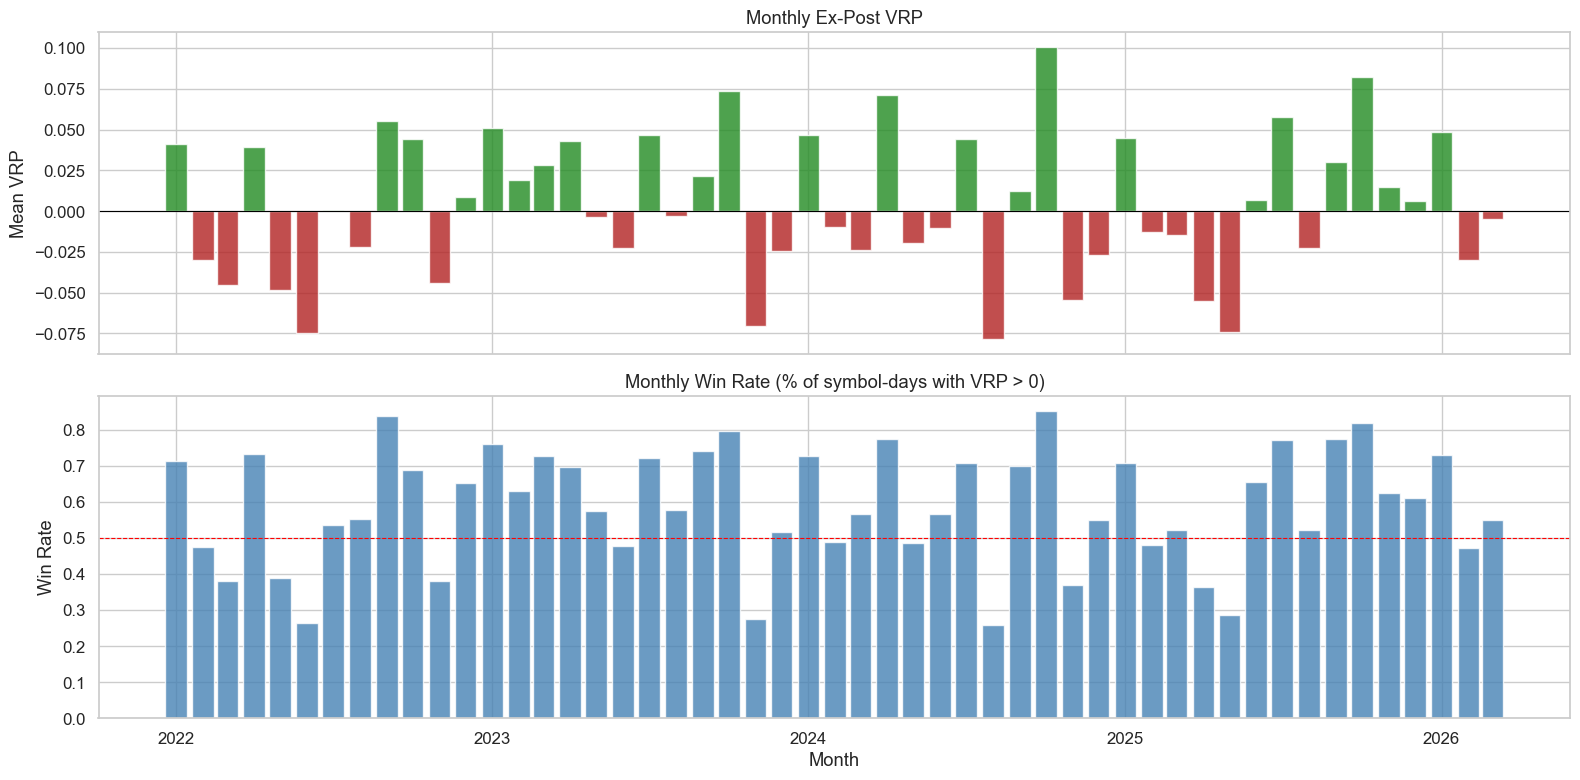

In [5]:
m = monthly.to_pandas()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

colors = ["forestgreen" if v > 0 else "firebrick" for v in m["mean_vrp"]]
ax1.bar(m["month"], m["mean_vrp"], color=colors, width=25, alpha=0.8)
ax1.axhline(0, color="black", lw=0.8)
ax1.set_ylabel("Mean VRP")
ax1.set_title("Monthly Ex-Post VRP")

ax2.bar(m["month"], m["win_rate"], color="steelblue", width=25, alpha=0.8)
ax2.axhline(0.5, color="red", ls="--", lw=0.8)
ax2.set_ylabel("Win Rate")
ax2.set_xlabel("Month")
ax2.set_title("Monthly Win Rate (% of symbol-days with VRP > 0)")
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

## 4. Symbol Rankings

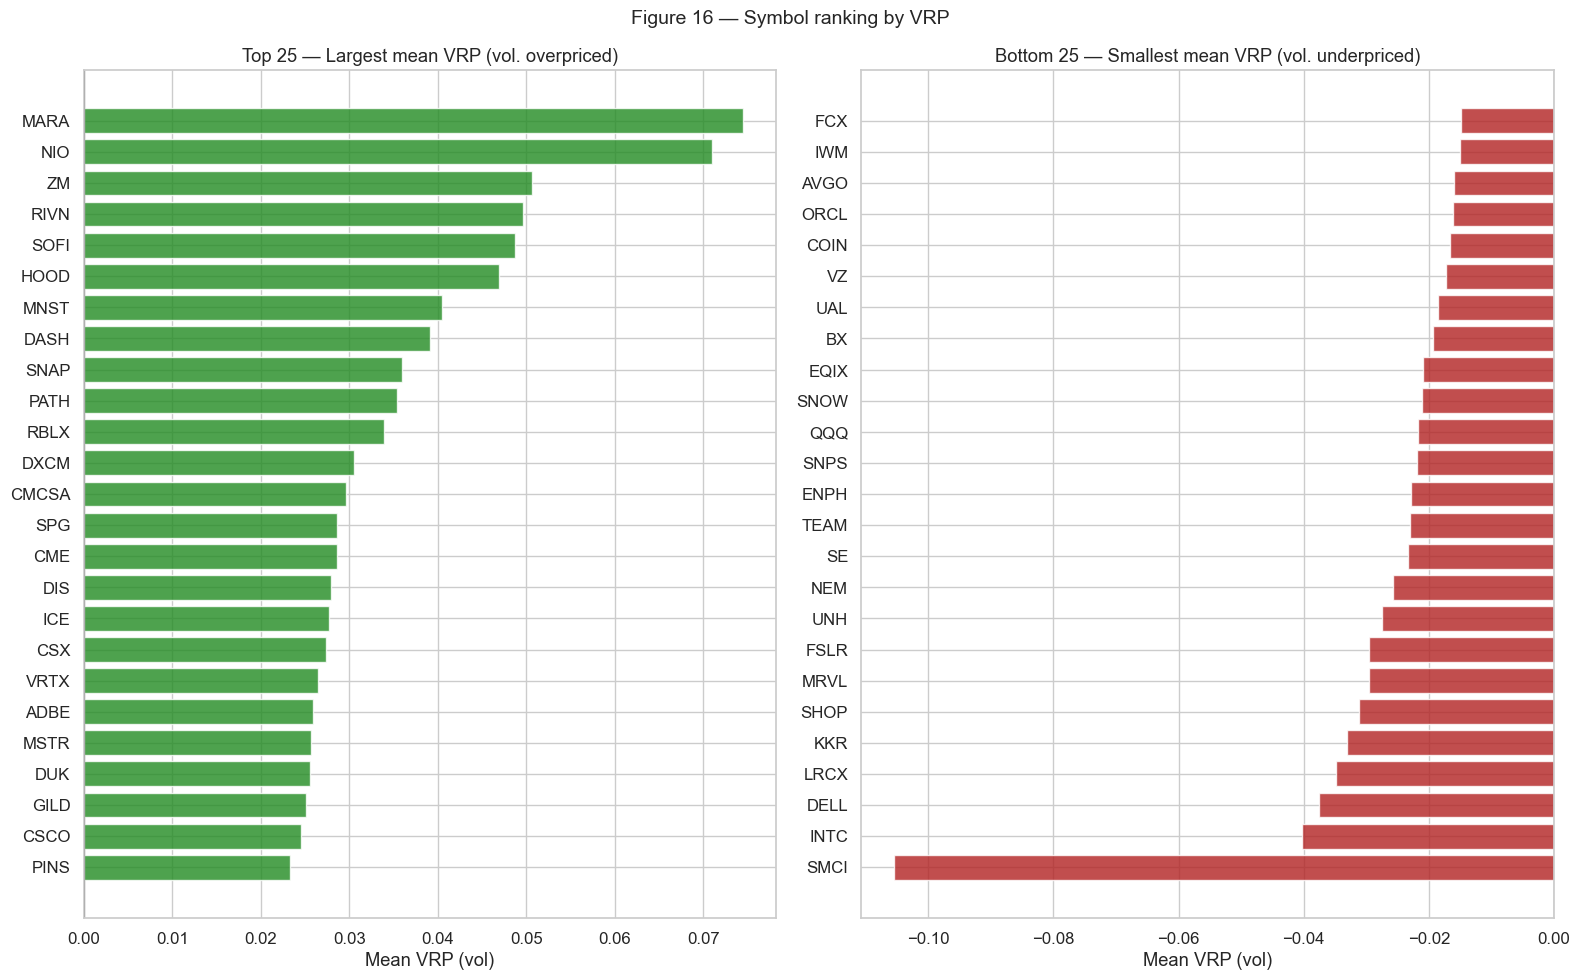

In [6]:
s = sym.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Top 25
top25 = s.head(25).iloc[::-1]
colors_t = ["forestgreen" if v > 0 else "firebrick" for v in top25["mean_vrp"]]
axes[0].barh(top25["symbol"], top25["mean_vrp"], color=colors_t, alpha=0.8)
axes[0].set_xlabel("Mean VRP (vol)")
axes[0].set_title("Top 25 — Largest mean VRP (vol. overpriced)")
axes[0].axvline(0, color="black", lw=0.8)

# Bottom 25
bot25 = s.tail(25).iloc[::-1]
colors_b = ["forestgreen" if v > 0 else "firebrick" for v in bot25["mean_vrp"]]
axes[1].barh(bot25["symbol"], bot25["mean_vrp"], color=colors_b, alpha=0.8)
axes[1].set_xlabel("Mean VRP (vol)")
axes[1].set_title("Bottom 25 — Smallest mean VRP (vol. underpriced)")
axes[1].axvline(0, color="black", lw=0.8)

fig.suptitle("Figure 16 — Symbol ranking by VRP", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Win Rate vs Mean VRP (Scatter)

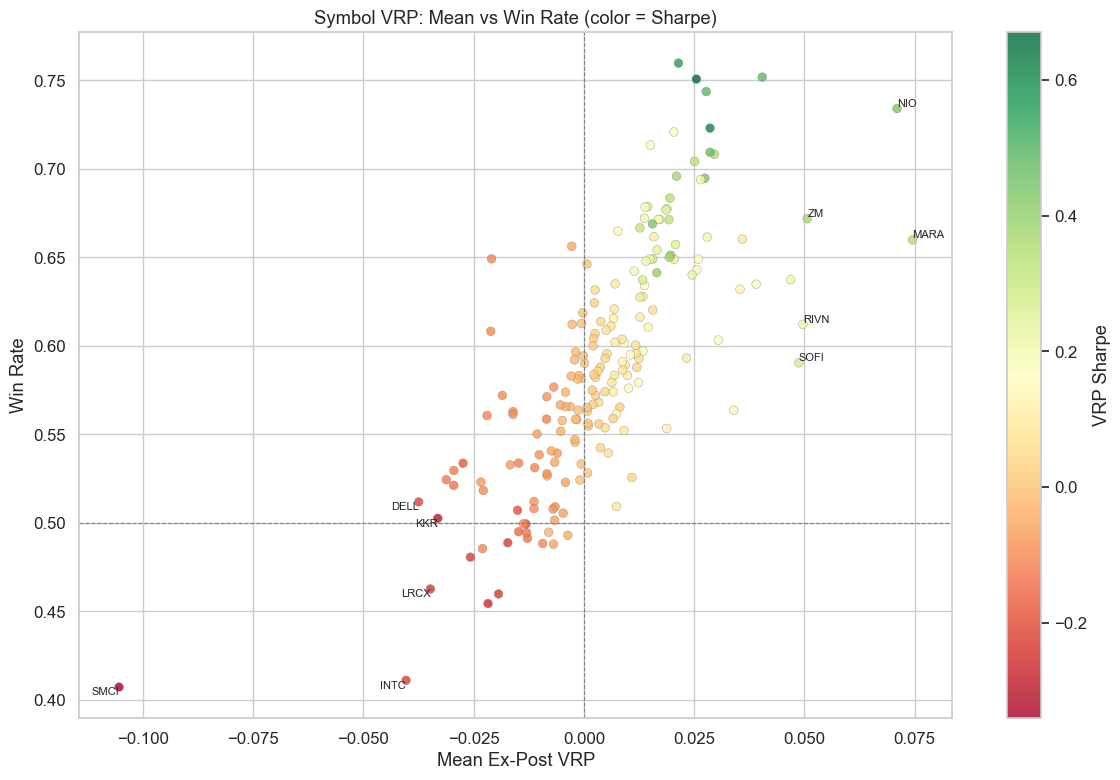

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(s["mean_vrp"], s["win_rate"], c=s["vrp_sharpe"],
                     cmap="RdYlGn", s=40, alpha=0.8, edgecolors="gray", lw=0.3)
plt.colorbar(scatter, label="VRP Sharpe")

# Label outliers
for _, row in s.head(5).iterrows():
    ax.annotate(row["symbol"], (row["mean_vrp"], row["win_rate"]),
                fontsize=8, ha="left", va="bottom")
for _, row in s.tail(5).iterrows():
    ax.annotate(row["symbol"], (row["mean_vrp"], row["win_rate"]),
                fontsize=8, ha="right", va="top")

ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Mean Ex-Post VRP")
ax.set_ylabel("Win Rate")
ax.set_title("Symbol VRP: Mean vs Win Rate (color = Sharpe)")
plt.tight_layout()
plt.show()

## 6. VRP Heatmap by Symbol × Year

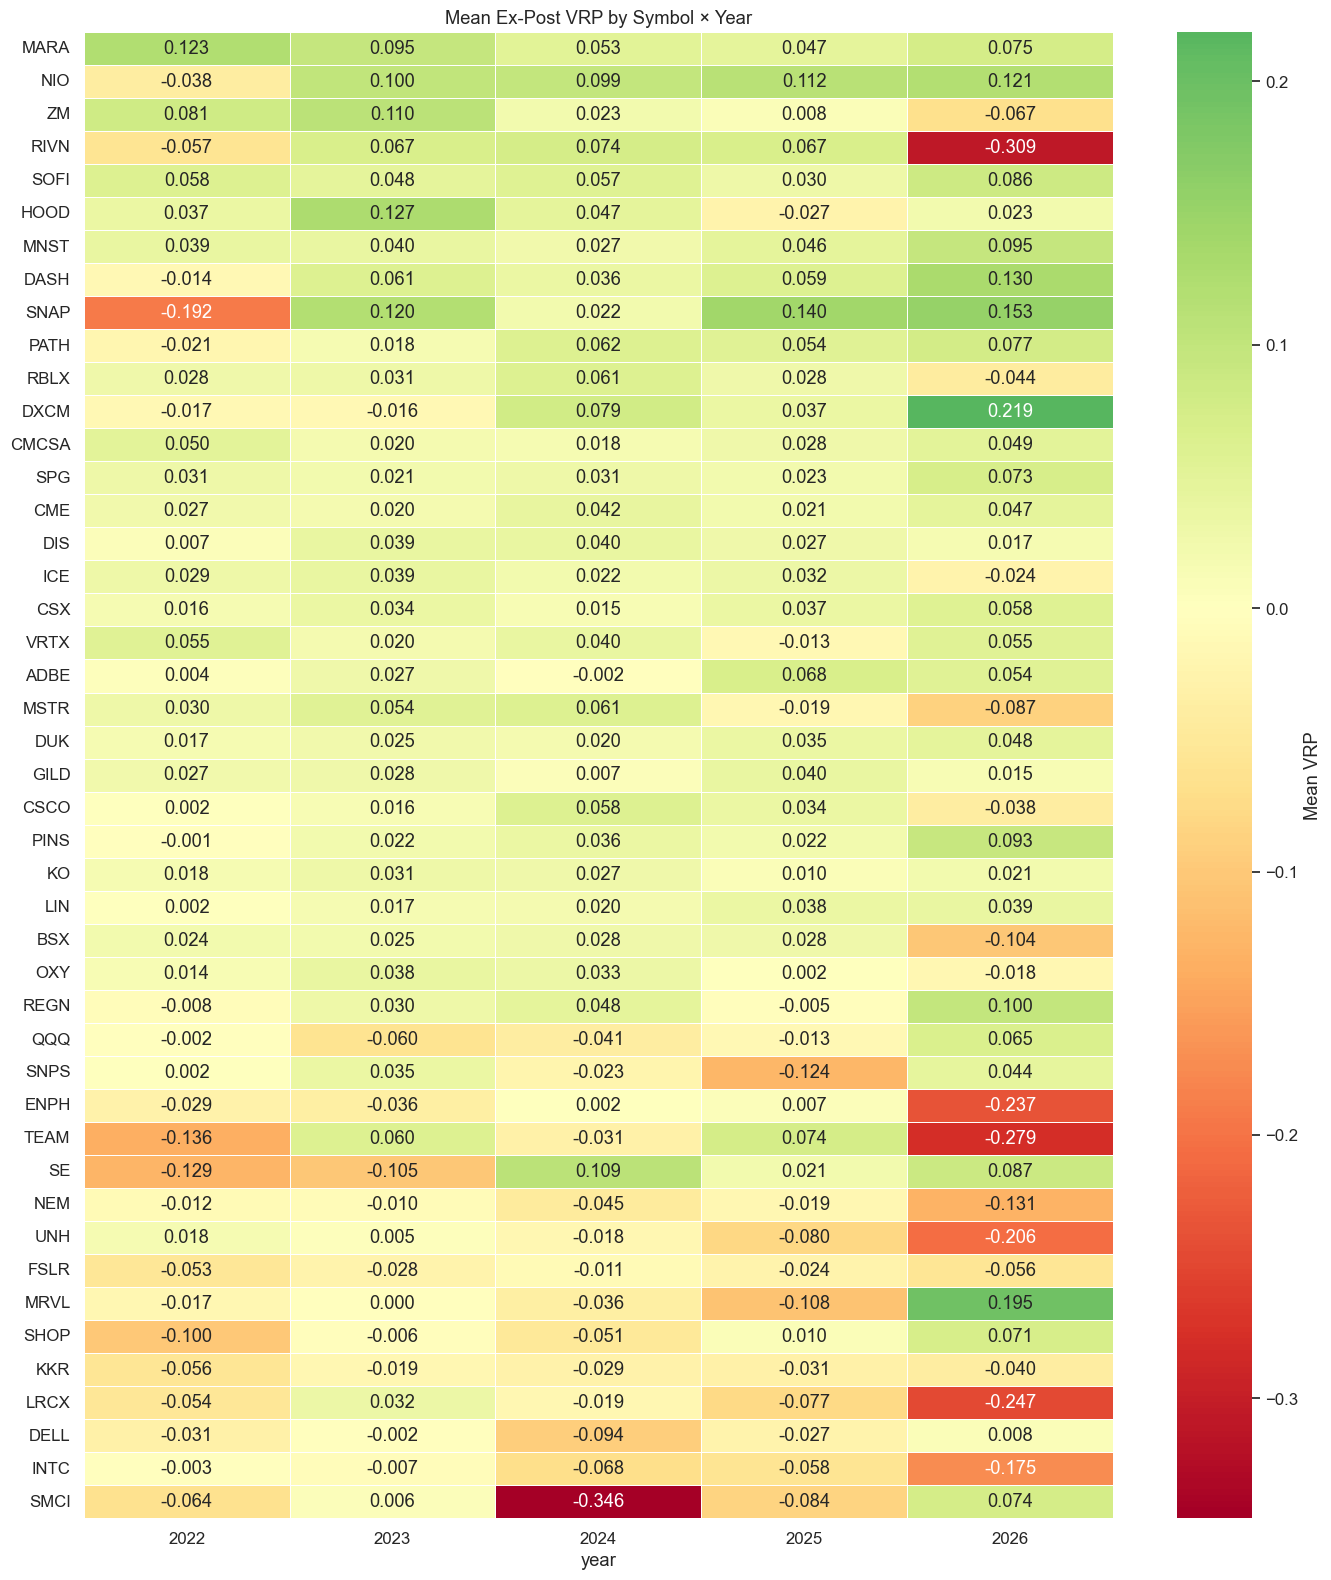

In [8]:
# Pick top 30 + bottom 15 by absolute mean VRP for readability
interesting = list(s.head(30)["symbol"]) + list(s.tail(15)["symbol"])

heat_data = (
    df.filter(pl.col("symbol").is_in(interesting))
    .with_columns(pl.col("date").dt.year().alias("year"))
    .group_by("symbol", "year")
    .agg(pl.col("vrp_expost").mean().alias("mean_vrp"))
    .sort("year")
    .to_pandas()
    .pivot(index="symbol", columns="year", values="mean_vrp")
)

# Sort by overall mean
order = s[s["symbol"].isin(interesting)].sort_values("mean_vrp", ascending=False)["symbol"]
heat_data = heat_data.reindex(order)

fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(heat_data, cmap="RdYlGn", center=0, annot=True, fmt=".3f",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Mean VRP"})
ax.set_title("Mean Ex-Post VRP by Symbol × Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. VRP Around Earnings

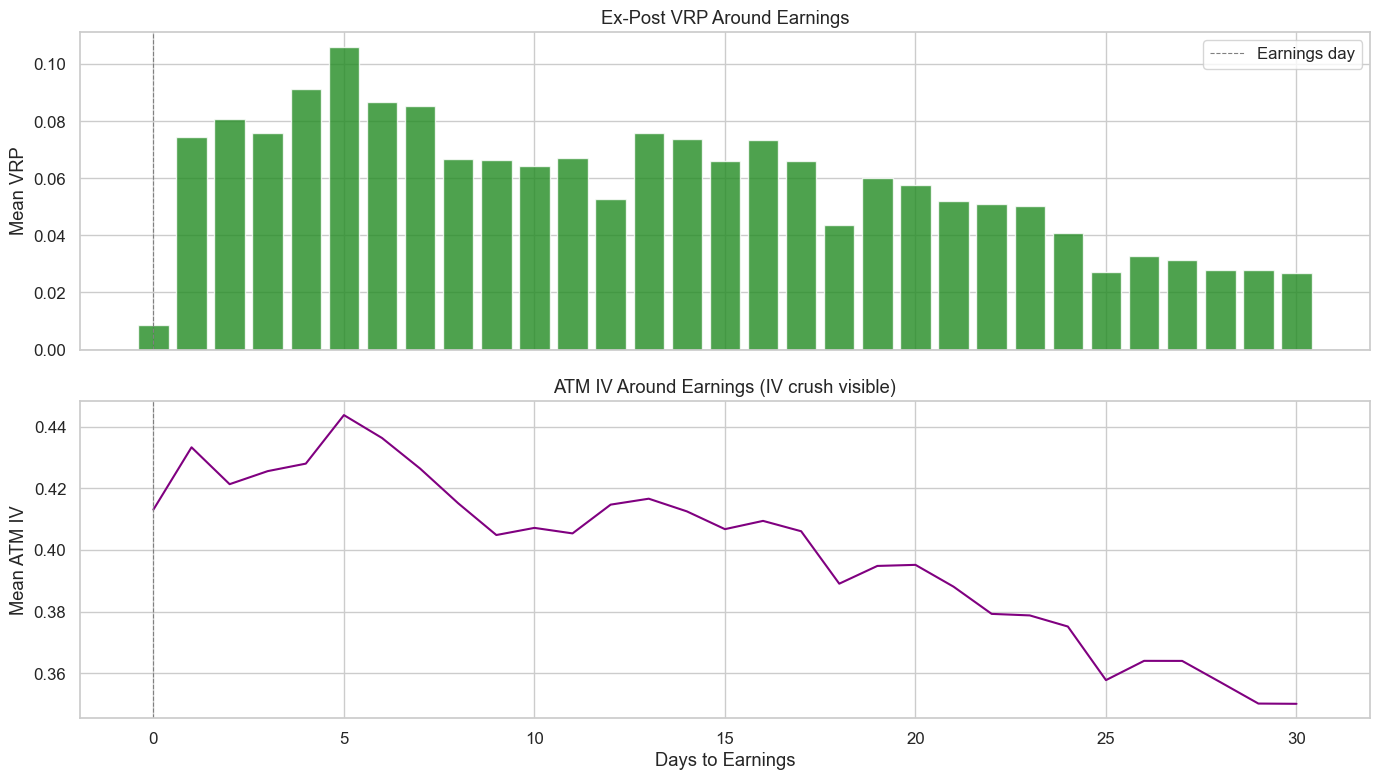

In [9]:
# How does VRP behave near earnings?
earn = df.filter(pl.col("days_to_earnings").is_not_null())

earn_vrp = (
    earn.filter(pl.col("days_to_earnings").abs() <= 30)
    .with_columns(pl.col("days_to_earnings").cast(pl.Int32).alias("dte"))
    .group_by("dte")
    .agg(
        pl.col("vrp_expost").mean().alias("mean_vrp"),
        pl.col("vrp_expost").median().alias("median_vrp"),
        pl.col("atm_iv").mean().alias("mean_iv"),
        pl.len().alias("n"),
    )
    .sort("dte")
    .to_pandas()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.bar(earn_vrp["dte"], earn_vrp["mean_vrp"],
        color=["forestgreen" if v > 0 else "firebrick" for v in earn_vrp["mean_vrp"]],
        alpha=0.8)
ax1.axhline(0, color="black", lw=0.8)
ax1.axvline(0, color="gray", ls="--", lw=0.8, label="Earnings day")
ax1.set_ylabel("Mean VRP")
ax1.set_title("Ex-Post VRP Around Earnings")
ax1.legend()

ax2.plot(earn_vrp["dte"], earn_vrp["mean_iv"], color="purple", lw=1.5)
ax2.axvline(0, color="gray", ls="--", lw=0.8)
ax2.set_ylabel("Mean ATM IV")
ax2.set_xlabel("Days to Earnings")
ax2.set_title("ATM IV Around Earnings (IV crush visible)")

plt.tight_layout()
plt.show()

## 8. Extreme Days

In [10]:
print("Top 20 — Biggest VRP (vol sellers won big):")
print(top.to_pandas().to_string(index=False))
print()
print("Bottom 20 — Worst VRP (vol sellers got crushed):")
print(bottom.to_pandas().to_string(index=False))

Top 20 — Biggest VRP (vol sellers won big):
symbol       date   atm_iv  rv_21d_forward  vrp_expost
  SNAP 2024-10-28 1.361085        0.113653    1.023961
  RIVN 2024-11-01 1.224770        0.080368    0.941277
  AFRM 2022-05-05 1.791867        0.743128    0.929819
  RIVN 2024-10-31 1.239056        0.099874    0.923027
  SNAP 2024-02-02 1.349875        0.186816    0.917653
  SNAP 2024-10-24 1.229963        0.112592    0.894415
  RIVN 2024-10-30 1.210728        0.100148    0.894266
  SNAP 2024-10-25 1.220339        0.110437    0.888019
  AFRM 2023-05-03 1.506640        0.422512    0.856631
   TTD 2025-11-06 1.290125        0.191846    0.852123
    SE 2024-02-28 1.223914        0.139032    0.851044
  RIVN 2024-10-29 1.154840        0.093057    0.849787
  SNAP 2024-01-31 1.247095        0.158970    0.848385
  SNAP 2024-02-01 1.280740        0.190048    0.844796
  SNAP 2024-04-24 1.272043        0.184007    0.843082
  SNAP 2024-10-22 1.159539        0.106385    0.833372
  SNAP 2023-01-30 1.3

## 9. Sector Analysis

            mean_vrp  median_vrp  mean_win  n_symbols
sector                                               
Crypto      0.050088    0.050088  0.651402          2
EV          0.032615    0.049663  0.621493          3
Media       0.027960    0.027960  0.661448          1
Util/REIT   0.013420    0.015315  0.677407         10
Materials   0.009345    0.003842  0.631697          3
Consumer    0.008046    0.007407  0.612265         15
Fin         0.008005    0.007535  0.616968         22
Other       0.003933    0.004258  0.579686         54
Industrial  0.001535    0.000369  0.590620         14
Health      0.001439    0.006699  0.588030         13
Tech       -0.001171   -0.001297  0.556274         41
Telecom    -0.002915   -0.005245  0.558225          3
Semis      -0.003411    0.001022  0.557109          3
Energy     -0.005032   -0.002893  0.563016          9


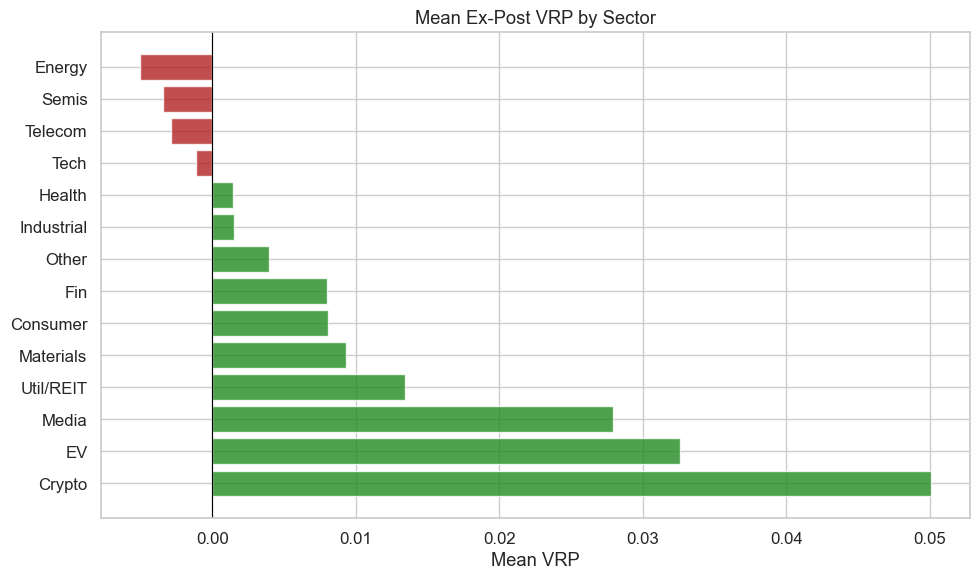

In [11]:
# Quick sector mapping for the universe
sector_map = {
    # Tech
    "AAPL": "Tech", "MSFT": "Tech", "NVDA": "Tech", "GOOG": "Tech", "AMZN": "Tech",
    "META": "Tech", "NFLX": "Tech", "CRM": "Tech", "ADBE": "Tech", "INTC": "Tech",
    "AMD": "Tech", "MU": "Tech", "QCOM": "Tech", "AMAT": "Tech", "LRCX": "Tech",
    "KLAC": "Tech", "MRVL": "Tech", "SNPS": "Tech", "CDNS": "Tech", "ANET": "Tech",
    "INTU": "Tech", "NOW": "Tech", "PANW": "Tech", "CRWD": "Tech", "ZS": "Tech",
    "DDOG": "Tech", "SNOW": "Tech", "NET": "Tech", "SMCI": "Tech", "DELL": "Tech",
    "SHOP": "Tech", "SQ": "Tech", "COIN": "Tech", "PATH": "Tech", "ZM": "Tech",
    "SNAP": "Tech", "RBLX": "Tech", "PLTR": "Tech", "UBER": "Tech", "DASH": "Tech",
    "SOFI": "Tech", "HOOD": "Tech",
    # Semis
    "AVGO": "Semis", "TXN": "Semis", "ON": "Semis",
    # Financials
    "JPM": "Fin", "BAC": "Fin", "GS": "Fin", "MS": "Fin", "C": "Fin",
    "WFC": "Fin", "BLK": "Fin", "KKR": "Fin", "COF": "Fin", "CME": "Fin",
    "ICE": "Fin", "SPGI": "Fin", "AIG": "Fin", "MET": "Fin", "AFL": "Fin",
    "CB": "Fin", "TRV": "Fin", "PGR": "Fin",
    # Healthcare
    "JNJ": "Health", "UNH": "Health", "PFE": "Health", "ABBV": "Health", "LLY": "Health",
    "MRK": "Health", "TMO": "Health", "ABT": "Health", "DHR": "Health", "MDT": "Health",
    "HCA": "Health", "ELV": "Health", "MRNA": "Health", "BIIB": "Health",
    # Consumer
    "TSLA": "Consumer", "HD": "Consumer", "NKE": "Consumer", "SBUX": "Consumer",
    "MCD": "Consumer", "TGT": "Consumer", "COST": "Consumer", "WMT": "Consumer",
    "PG": "Consumer", "KO": "Consumer", "PEP": "Consumer", "PM": "Consumer",
    "MO": "Consumer", "MNST": "Consumer", "CMG": "Consumer",
    # Industrials
    "CAT": "Industrial", "DE": "Industrial", "RTX": "Industrial", "BA": "Industrial",
    "HON": "Industrial", "GE": "Industrial", "MMM": "Industrial", "UNP": "Industrial",
    "CSX": "Industrial", "NOC": "Industrial", "GD": "Industrial", "DAL": "Industrial",
    "UAL": "Industrial", "FDX": "Industrial",
    # Energy
    "XOM": "Energy", "CVX": "Energy", "COP": "Energy", "SLB": "Energy",
    "OXY": "Energy", "FCX": "Energy", "NEM": "Energy", "NUE": "Energy",
    "FSLR": "Energy",
    # Crypto/Meme
    "MARA": "Crypto", "MSTR": "Crypto",
    # EV/Growth
    "NIO": "EV", "RIVN": "EV", "LCID": "EV", "ENPH": "EV",
    # Utilities/REITs
    "D": "Util/REIT", "DUK": "Util/REIT", "SO": "Util/REIT", "SRE": "Util/REIT",
    "O": "Util/REIT", "AMT": "Util/REIT", "PLD": "Util/REIT", "PSA": "Util/REIT",
    "EQIX": "Util/REIT", "SPG": "Util/REIT",
    # Telecom
    "TMUS": "Telecom", "T": "Telecom", "VZ": "Telecom",
    # Other
    "DIS": "Media", "PYPL": "Fin", "V": "Fin", "MA": "Fin", "AXP": "Fin",
    "DOW": "Materials", "LIN": "Materials", "SHW": "Materials",
}

s_sec = s.copy()
s_sec["sector"] = s_sec["symbol"].map(sector_map).fillna("Other")

sector_agg = s_sec.groupby("sector").agg(
    mean_vrp=("mean_vrp", "mean"),
    median_vrp=("mean_vrp", "median"),
    mean_win=("win_rate", "mean"),
    n_symbols=("symbol", "count"),
).sort_values("mean_vrp", ascending=False)

print(sector_agg.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["forestgreen" if v > 0 else "firebrick" for v in sector_agg["mean_vrp"]]
ax.barh(sector_agg.index, sector_agg["mean_vrp"], color=colors, alpha=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean VRP")
ax.set_title("Mean Ex-Post VRP by Sector")
plt.tight_layout()
plt.show()

## 10. IV vs Realized Vol vs LightGBM Forecast — Case Studies

LightGBM is the walk-forward robust winner (WF QLIKE=0.0231, -17.5% vs LogHAR).
Single-split test period forecasts shown below.

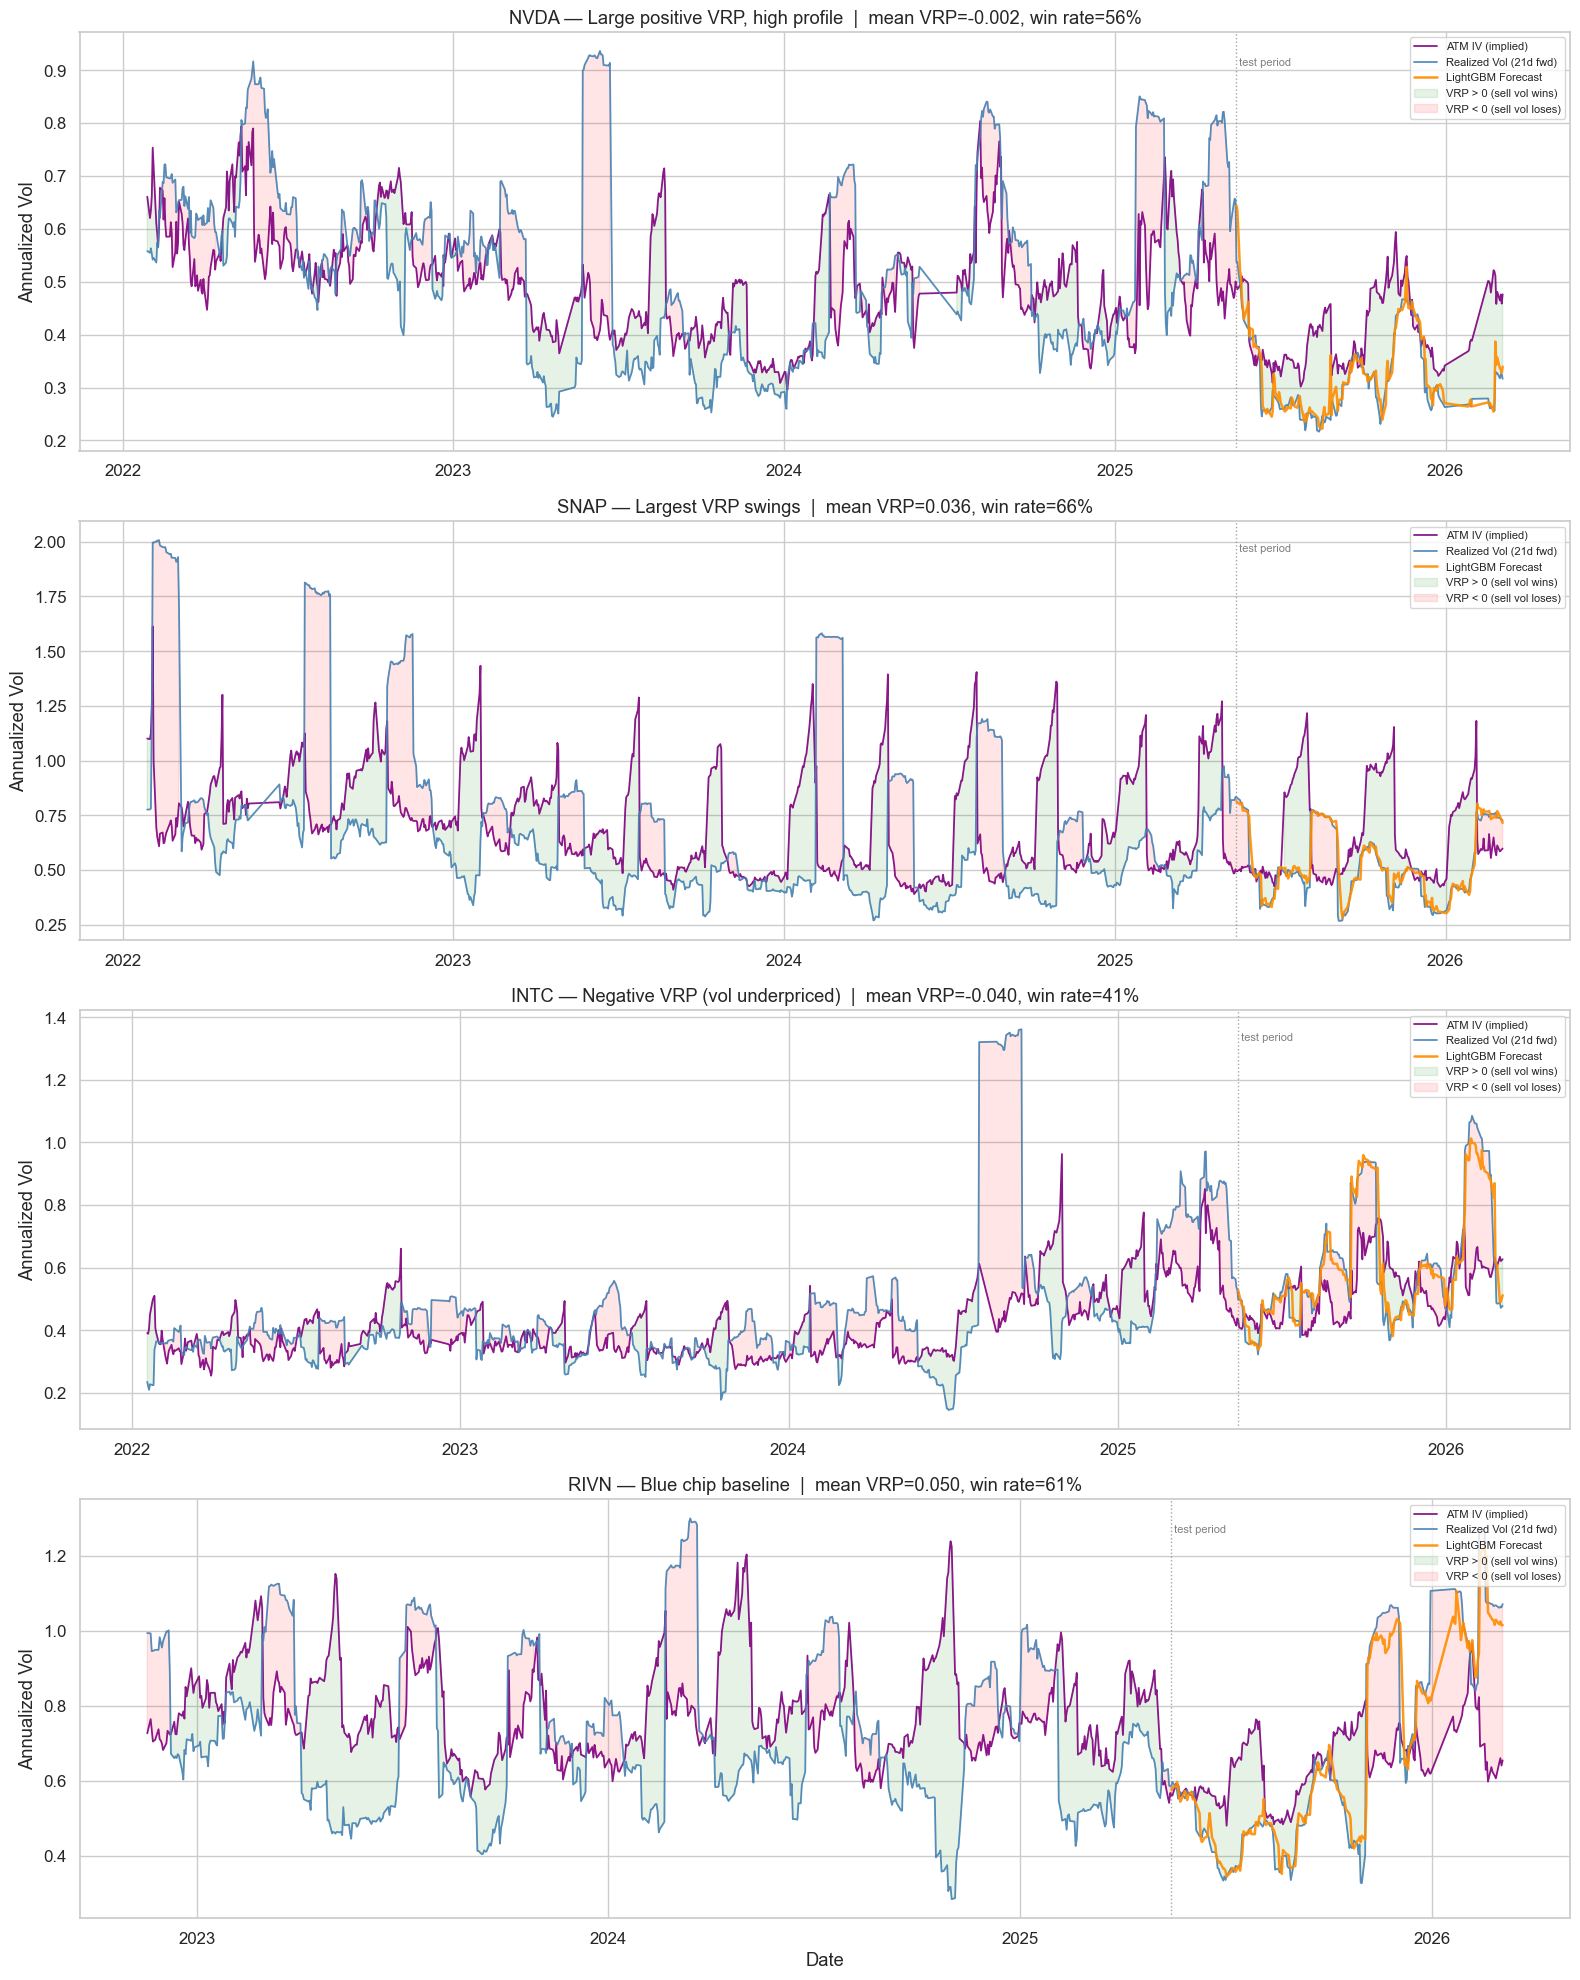

In [12]:
# Load LightGBM predictions and merge with panel
lgbm = pl.read_parquet("../data/processed/predictions/lgbm.parquet")

# Build per-symbol time series: IV, realized vol, LightGBM forecast (all in vol space)
panel_vol = (
    df.select("symbol", "date", "atm_iv", "rv_21d_forward", "vrp_expost")
    .with_columns(pl.col("rv_21d_forward").sqrt().alias("rv_vol"))
)

# LightGBM y_pred is in variance space (level) — convert to vol
lgbm_vol = (
    lgbm.select("symbol", "date", "y_pred")
    .with_columns(pl.col("y_pred").sqrt().alias("lgbm_vol"))
    .select("symbol", "date", "lgbm_vol")
)

merged = panel_vol.join(lgbm_vol, on=["symbol", "date"], how="left")

def plot_iv_rv_lgbm(symbol: str, ax: plt.Axes, title_suffix: str = ""):
    """Plot IV, realized vol, and LightGBM forecast for a single symbol."""
    s = merged.filter(pl.col("symbol") == symbol).sort("date").to_pandas()

    ax.plot(s["date"], s["atm_iv"], color="purple", lw=1.3, label="ATM IV (implied)", alpha=0.9)
    ax.plot(s["date"], s["rv_vol"], color="steelblue", lw=1.3, label="Realized Vol (21d fwd)", alpha=0.9)

    # LightGBM only available in test period
    lgbm_mask = s["lgbm_vol"].notna()
    ax.plot(s.loc[lgbm_mask, "date"], s.loc[lgbm_mask, "lgbm_vol"],
            color="darkorange", lw=1.8, label="LightGBM Forecast", alpha=0.9)

    # Shade VRP: green where IV > RV (positive VRP), red where IV < RV
    ax.fill_between(s["date"], s["atm_iv"], s["rv_vol"],
                    where=s["atm_iv"] >= s["rv_vol"],
                    color="green", alpha=0.1, label="VRP > 0 (sell vol wins)")
    ax.fill_between(s["date"], s["atm_iv"], s["rv_vol"],
                    where=s["atm_iv"] < s["rv_vol"],
                    color="red", alpha=0.1, label="VRP < 0 (sell vol loses)")

    # Mark test period start
    test_start = s.loc[lgbm_mask, "date"].min()
    if not lgbm_mask.all():
        ax.axvline(test_start, color="gray", ls=":", lw=1, alpha=0.7)
        ax.text(test_start, ax.get_ylim()[1] * 0.95, " test period",
                fontsize=8, color="gray", va="top")

    mean_vrp = s["vrp_expost"].mean()
    win_rate = (s["vrp_expost"] > 0).mean()
    ax.set_title(f"{symbol}{title_suffix}  |  mean VRP={mean_vrp:.3f}, win rate={win_rate:.0%}")
    ax.set_ylabel("Annualized Vol")
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# --- Plot 4 interesting symbols ---
symbols = [
    ("NVDA", " — Large positive VRP, high profile"),
    ("SNAP", " — Largest VRP swings"),
    ("INTC", " — Negative VRP (vol underpriced)"),
    ("RIVN", " — Blue chip baseline"),
]

fig, axes = plt.subplots(len(symbols), 1, figsize=(16, 5 * len(symbols)), sharex=False)
for ax, (sym, desc) in zip(axes, symbols):
    plot_iv_rv_lgbm(sym, ax, desc)
    ax.set_xlabel("")
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 11. Walk-Forward Forecasts vs IV & Realized Vol

12 expanding windows (quarterly, 2023-02 to 2026-02). Each window the model is retrained on all
available history. This shows how LightGBM tracks realized vol across regime changes — and where
implied vol diverges (= VRP opportunity).

Three layers per symbol:
- **Purple:** ATM IV (market's implied forecast)
- **Blue:** Realized Vol (21d forward, ex-post truth)
- **Orange / Gray:** LightGBM / LogHAR walk-forward forecasts (retrained each window)

In [13]:
import json as _json

# --- Load walk-forward predictions ---
wf_preds = pl.read_parquet("../data/processed/evaluation/walk_forward/all_predictions.parquet")

with open("../data/processed/evaluation/walk_forward/window_schedule.json") as f:
    window_schedule = _json.load(f)

# Filter to LightGBM and LogHAR
wf = wf_preds.filter(pl.col("model").is_in(["LightGBM", "LogHAR"]))

# Convert to vol space (sqrt of variance)
wf = wf.with_columns(
    pl.col("y_true").sqrt().alias("rv_vol"),
    pl.col("y_pred").sqrt().alias("forecast_vol"),
)

# Join with panel to get ATM IV
panel_iv = panel.select("symbol", "date", "atm_iv")
wf = wf.join(panel_iv, on=["symbol", "date"], how="left")

# Window test-period start dates for vertical markers
from datetime import date as _date
window_starts = [_date.fromisoformat(w["test_start"]) for w in window_schedule]

print(f"Walk-forward predictions: {wf.shape[0]:,} rows")
print(f"Models: {sorted(wf['model'].unique().to_list())}")
print(f"Date range: {wf['date'].min()} to {wf['date'].max()}")
print(f"Windows: {len(window_schedule)}")

Walk-forward predictions: 276,791 rows
Models: ['LightGBM', 'LogHAR']
Date range: 2023-02-07 to 2026-02-19
Windows: 12


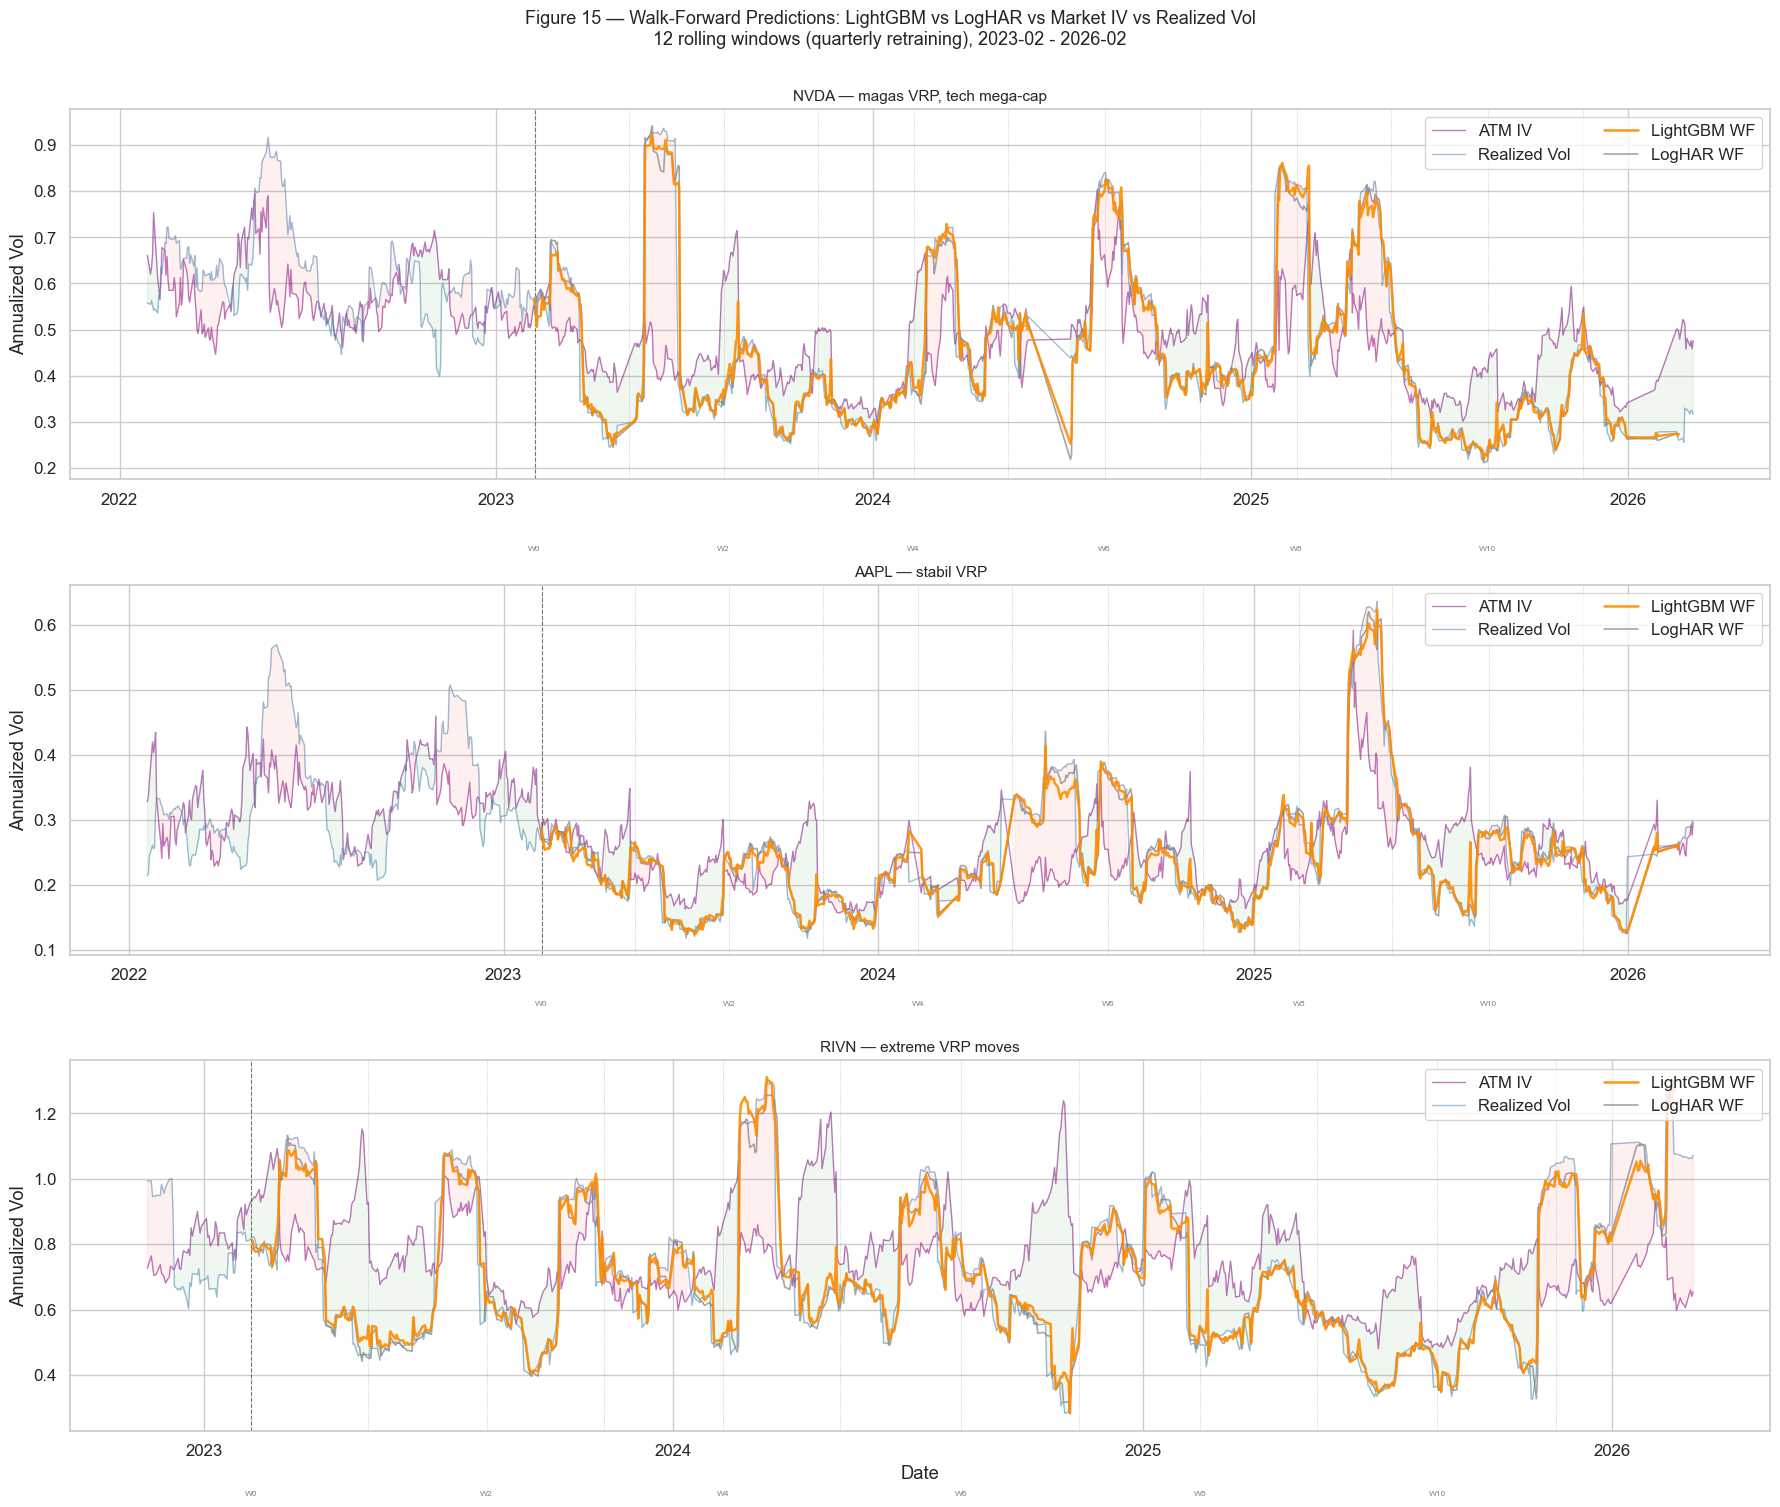

In [14]:
def plot_wf_timeline(symbol: str, ax: plt.Axes, title_suffix: str = ""):
    """Walk-forward timeline: IV, realized vol, LightGBM & LogHAR forecasts."""
    # Full panel history for IV and RV
    full = (
        df.filter(pl.col("symbol") == symbol)
        .select("date", "atm_iv", "rv_21d_forward")
        .with_columns(pl.col("rv_21d_forward").sqrt().alias("rv_vol"))
        .sort("date")
        .to_pandas()
    )

    # Walk-forward forecasts for this symbol
    wf_sym = wf.filter(pl.col("symbol") == symbol).sort("date")
    lgbm_wf = wf_sym.filter(pl.col("model") == "LightGBM").to_pandas()
    loghar_wf = wf_sym.filter(pl.col("model") == "LogHAR").to_pandas()

    # Background: full history IV and RV
    ax.plot(full["date"], full["atm_iv"], color="purple", lw=1, alpha=0.5, label="ATM IV")
    ax.plot(full["date"], full["rv_vol"], color="steelblue", lw=1, alpha=0.5, label="Realized Vol")

    # VRP shading (full history)
    ax.fill_between(full["date"], full["atm_iv"], full["rv_vol"],
                    where=full["atm_iv"] >= full["rv_vol"],
                    color="green", alpha=0.06)
    ax.fill_between(full["date"], full["atm_iv"], full["rv_vol"],
                    where=full["atm_iv"] < full["rv_vol"],
                    color="red", alpha=0.06)

    # Walk-forward model forecasts (foreground, bolder)
    ax.plot(lgbm_wf["date"], lgbm_wf["forecast_vol"],
            color="darkorange", lw=1.8, alpha=0.9, label="LightGBM WF", zorder=5)
    ax.plot(loghar_wf["date"], loghar_wf["forecast_vol"],
            color="gray", lw=1.2, alpha=0.7, label="LogHAR WF", zorder=4)

    # Window boundaries
    for i, ws in enumerate(window_starts):
        ax.axvline(ws, color="black", ls=":", lw=0.5, alpha=0.3)
        if i % 2 == 0:  # label every other window to avoid clutter
            ax.text(ws, ax.get_ylim()[1] * 0.02, f"W{i}", fontsize=6,
                    color="gray", ha="center", va="bottom")

    # Mark walk-forward region start
    wf_start = lgbm_wf["date"].min() if len(lgbm_wf) > 0 else None
    if wf_start is not None:
        ax.axvline(wf_start, color="black", ls="--", lw=0.8, alpha=0.5)

    ax.set_title(f"{symbol}{title_suffix}", fontsize=11)
    ax.set_ylabel("Annualized Vol")
    ax.legend(loc="upper right", fontsize=12, ncol=2)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


# --- Plot same 4 symbols + 2 extra for diversity ---
wf_symbols = [
    ("NVDA", " — magas VRP, tech mega-cap"),
    ("AAPL", " — stabil VRP"),
    ("RIVN", " — extreme VRP moves"),
]

fig, axes = plt.subplots(len(wf_symbols), 1, figsize=(18, 5 * len(wf_symbols)), sharex=False)
for ax, (sym, desc) in zip(axes, wf_symbols):
    plot_wf_timeline(sym, ax, desc)
    ax.set_xlabel("")
axes[-1].set_xlabel("Date")

fig.suptitle("Figure 15 — Walk-Forward Predictions: LightGBM vs LogHAR vs Market IV vs Realized Vol\n"
             "12 rolling windows (quarterly retraining), 2023-02 - 2026-02",
             fontsize=13, y=1.001)
plt.tight_layout()
plt.show()